# Assess correlation between RBM scores and binding and expression data
Generate Figure 3ab and Figure S2

In [1]:
#show png Fig2PNAS in notebook
%matplotlib inline
import matplotlib.pyplot as plt#5,7 best:.42, .47; pnas: 18,5
BEGIN=18
END=5
#show png Fig2PNAS in notebook


In [2]:
import os, sys
pgm_path = '../PGM/'
sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')
sys.path.append('../')

In [ ]:
# imports

import rbm, RBM_utils

import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import utilities, Proteins_utils, sequence_logo, plots_utils 
from scipy.stats import spearmanr



e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1036: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1322: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Fasta processing

In [4]:
WT='SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCG'
len(WT)

178

In [5]:
wt_omicron=Proteins_utils.load_FASTA('exp_data/wt_omicron.fasta')
print('wt:', wt_omicron[0,BEGIN:-END])



wt: [15 17 19  0 18 11 14  8 14  7 15 11  1 17  0  2 19 15 17  9 19 11 15  0
 15  4 15 16  4  8  1 19  5 17 15 12 16  8  9 11  2  9  1  4 16 11 17 19
  0  2 15  4 17  7 14  5  2  3 17 14 13  7  0 12  5 13 16  5  8  7  0  2
 19 11 19  8  9 12  2  2  4 16  5  1 17  7  0 18 11 15 11 11  9  2 15  8
 17  5  5 11 19 11 19  9 19 14  9  4 14  8 15 11  9  8 12  4  3 14  2  7
 15 16  3  7 19 13  0  5 15 16 12  1 11  5 17  3  5  4 11  1 19  4 12  9
 13 15 19  5  4 13 12 16 11  5 17  5 19 13 12 19 14 17 17 17  9 15  4  3
  9  9  6  0 12  0 16 17  1  5]


# Comparison to experimental data

In [6]:
df_bloom=pd.read_csv('exp_data/starr_science/bloom_deep_scan_ACE2_with_sequence.csv')
df_bloom=df_bloom[df_bloom['site_SARS2']>=349] 
df_bloom=df_bloom[df_bloom['site_SARS2']<=526]
#reset index
df_bloom=df_bloom.reset_index(drop=True)
#sequence column to fasta file
with open('exp_data/starr_science/bloom_deep_scan_ACE2_with_sequence.fasta', 'w') as f:
    for index, row in df_bloom.iterrows():
        #if * in sequence, remove sequence
        if '*' in row['sequence']:
            continue
        f.write('>' + str(index) + '\n')
        f.write(row['sequence'] + '\n')
# df_bloom
bloom_sequences=Proteins_utils.load_FASTA('exp_data/starr_science/bloom_deep_scan_ACE2_with_sequence.fasta')
print('shape of sequences:', np.shape(bloom_sequences))
bloom_sequences = [seq[BEGIN:-END] for seq in bloom_sequences]
bloom_sequences=np.array(bloom_sequences)
# bloom_sequences=one_hot_encode_matrix(bloom_sequences)


shape of sequences: (3327, 201)


# Models

## esmif

In [7]:
df_esmif = pd.read_csv('exp_data/starr_science/bloom_esmif.csv')
df_bloom['esmif_likelihood'] = df_esmif['log_likelihood']-(-1.1953541863824904)

## RBM

In [ ]:
RBM=RBM_utils.loadRBM('rbms/ESMIF_RBM_wt_Covid_temp_1_nH_50_l1B_0.2.data')
# RBM=RBM_utils.loadRBM('wt_RBM_Covid.data')
sequences_likelihood = -RBM.free_energy(bloom_sequences)+RBM.free_energy(wt_omicron[0,BEGIN:-END])
df_bloom['likelihood'] = sequences_likelihood

# ESMIF distillation

mean RBM likelihood: -8.233626
mean RBM likelihood: -8.222433


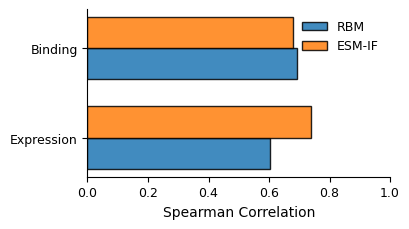

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- Load likelihoods ---


# --- Optional debug print ---
print('mean RBM likelihood:', df_bloom['likelihood'].mean())

# --- Aggregate per-site ---
df_bloom_avg = df_bloom.groupby('site_SARS2').agg(
    lambda x: x.mean() if np.issubdtype(x.dtype, np.number) else x.iloc[0]
).reset_index()
print('mean RBM likelihood:', df_bloom_avg['likelihood'].mean())

# --- Compute Spearman correlations ---
metrics = ['expr_avg', 'bind_avg']
methods = ['likelihood', 'esmif_likelihood']
labels = {'likelihood': 'RBM', 'esmif_likelihood': 'ESM-IF'}

corr_data = []
for met in metrics:
    for method in methods:
        rho, _ = spearmanr(df_bloom_avg[method], df_bloom_avg[met])
        corr_data.append((met, labels[method], rho))

# --- Convert to DataFrame for plotting ---
df_corr = pd.DataFrame(corr_data, columns=['Metric', 'Method', 'Spearman R'])

# --- Plot: Horizontal Bar Chart ---
fig, ax = plt.subplots(figsize=(4.2, 2.4))  # Small and tight for Nature

# Define position of bars
metric_order = ['expr_avg', 'bind_avg']
method_order = ['RBM', 'ESM-IF']
bar_height = 0.35
y = np.arange(len(metric_order))

# Plot horizontal bars side-by-side
offset = bar_height / 2
for i, method in enumerate(method_order):
    values = [
        df_corr.query("Metric == @met and Method == @method")["Spearman R"].values[0]
        for met in metric_order
    ]
    ax.barh(
        y + (i - 0.5) * offset * 2,  # Center around y
        values,
        height=bar_height,
        label=method,
        alpha=0.85,
        edgecolor='black'
    )

# Aesthetics
ax.set_yticks(y)
ax.set_yticklabels(['Expression', 'Binding'], fontsize=10)
ax.set_xlabel('Spearman Correlation', fontsize=10)
ax.set_xlim(0, 1)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.legend(frameon=False, loc='upper right', fontsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Correlations with experimental data

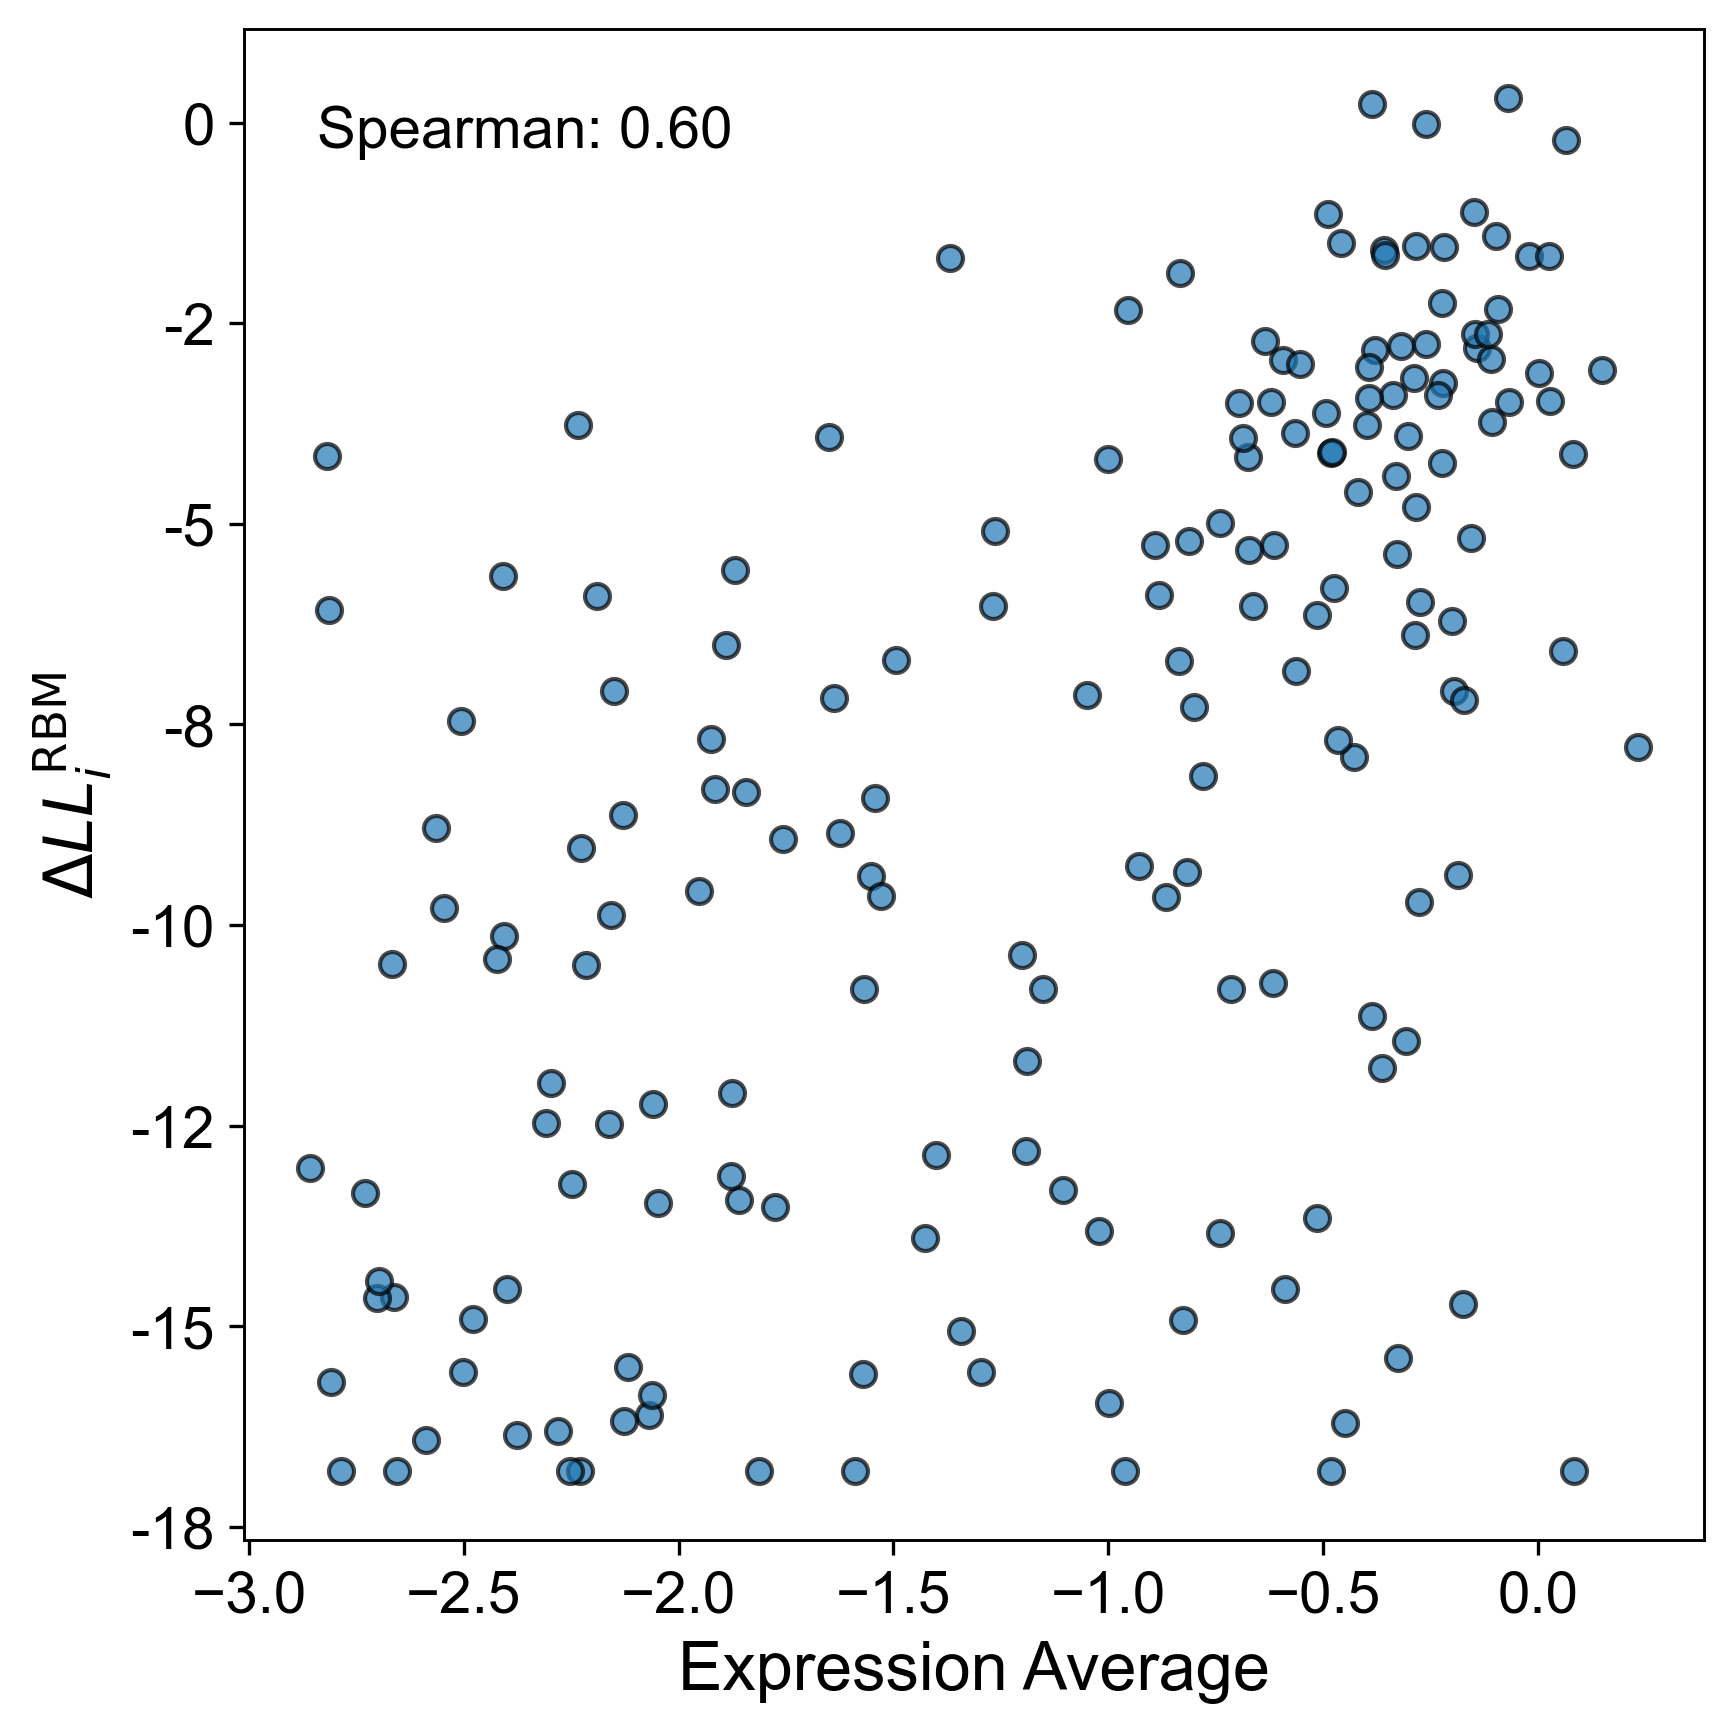

likelihood vs expr_avg
  Spearman: 0.602
  R² score: -89.252


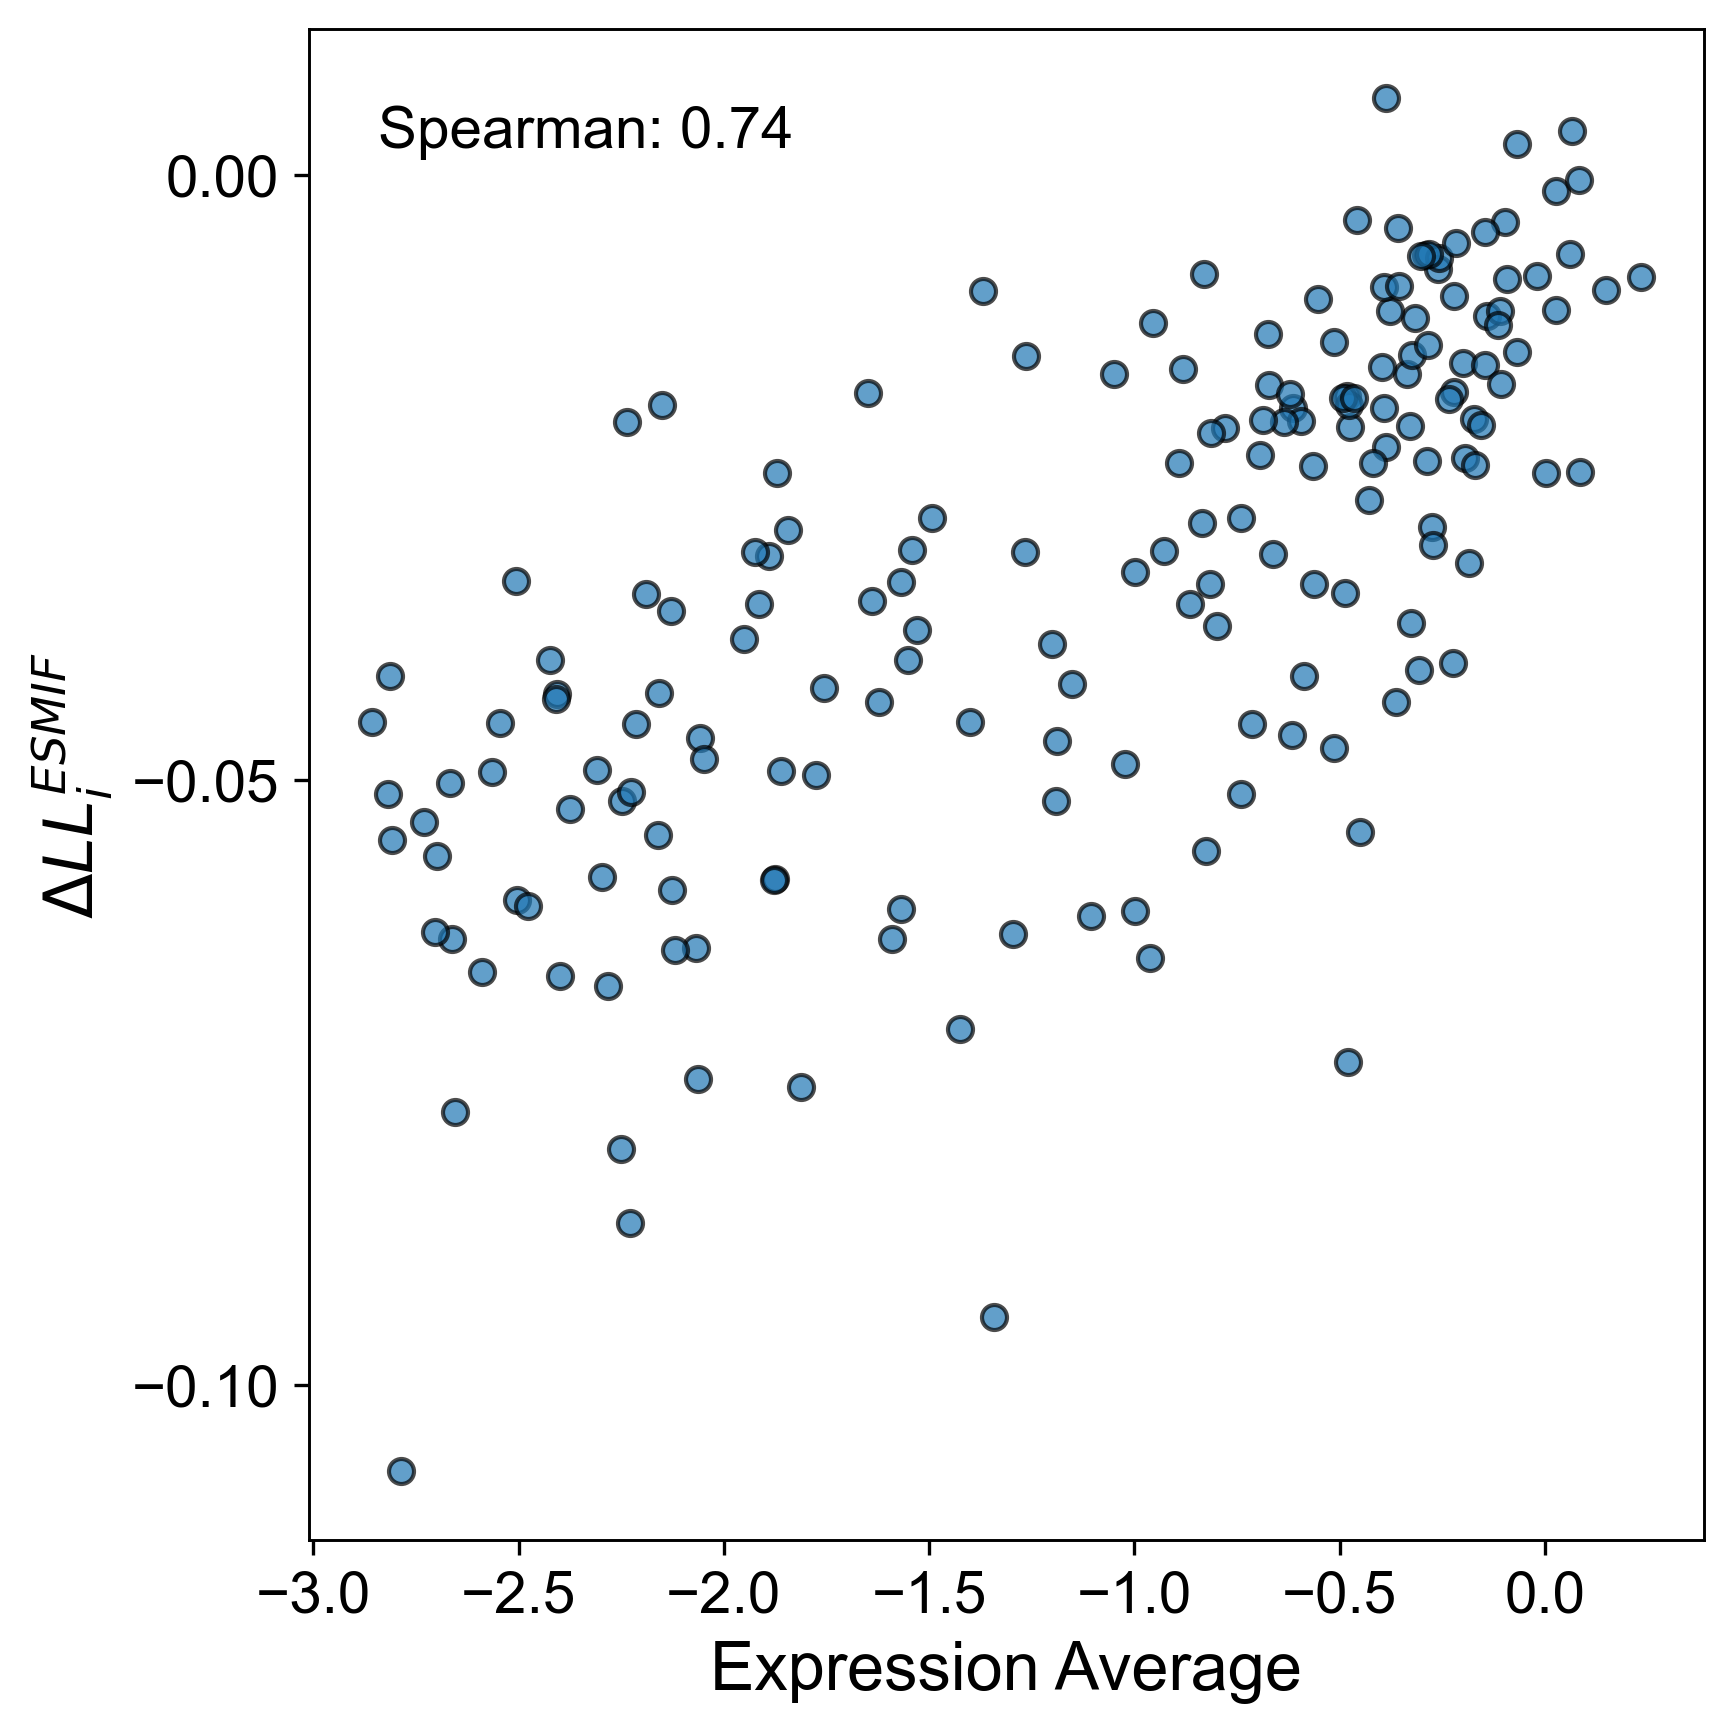

esmif_likelihood vs expr_avg
  Spearman: 0.738
  R² score: -1.430


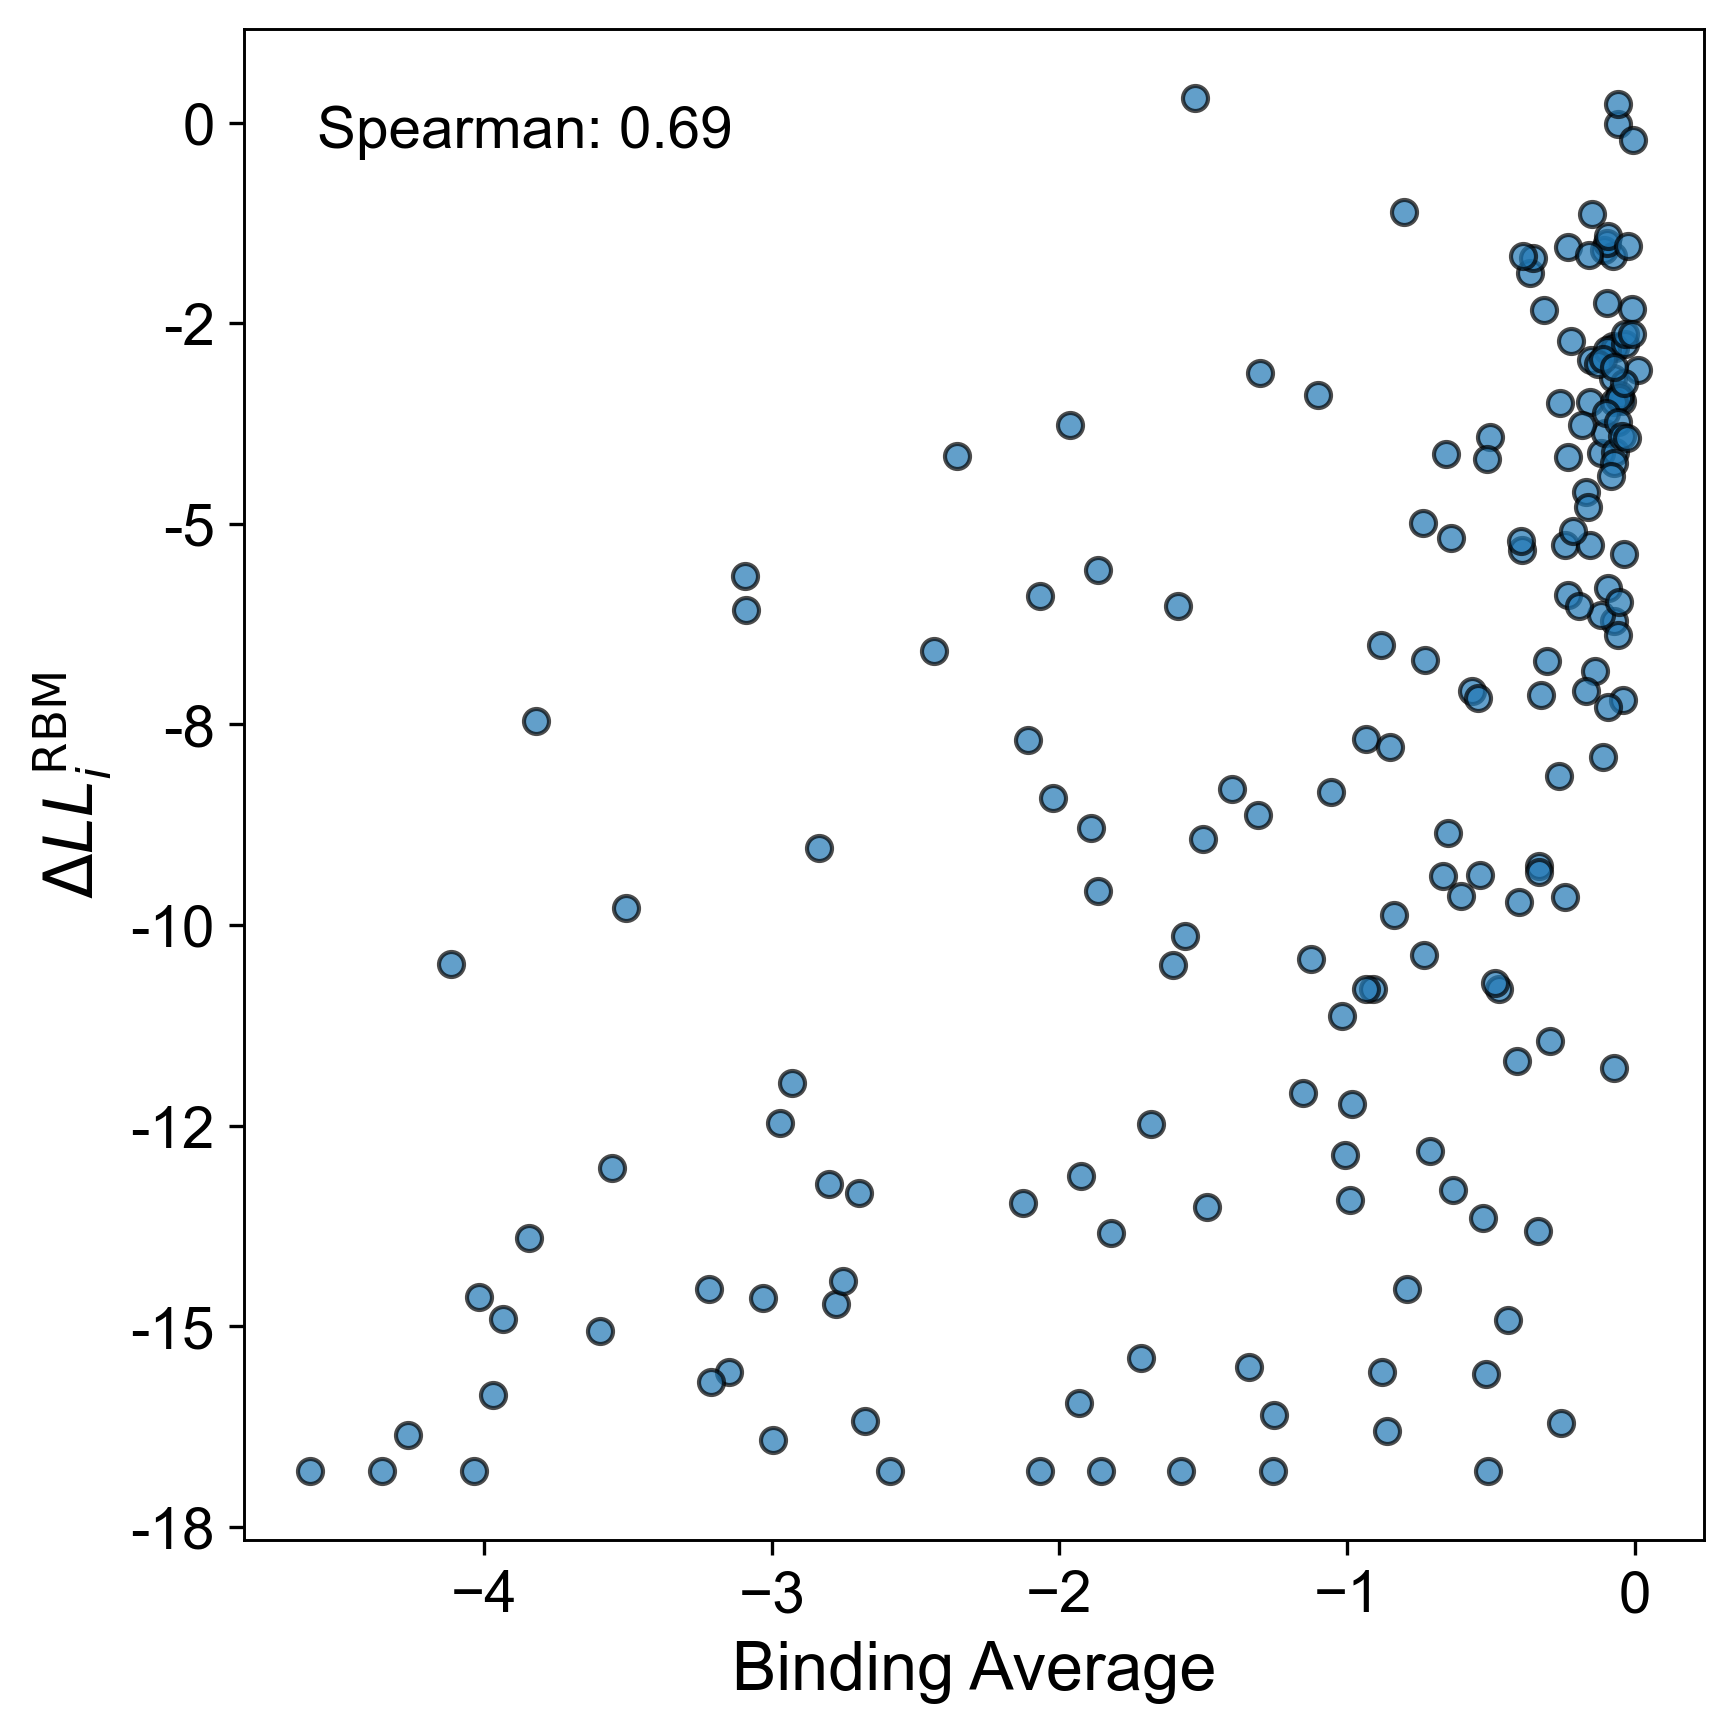

likelihood vs bind_avg
  Spearman: 0.693
  R² score: -47.388


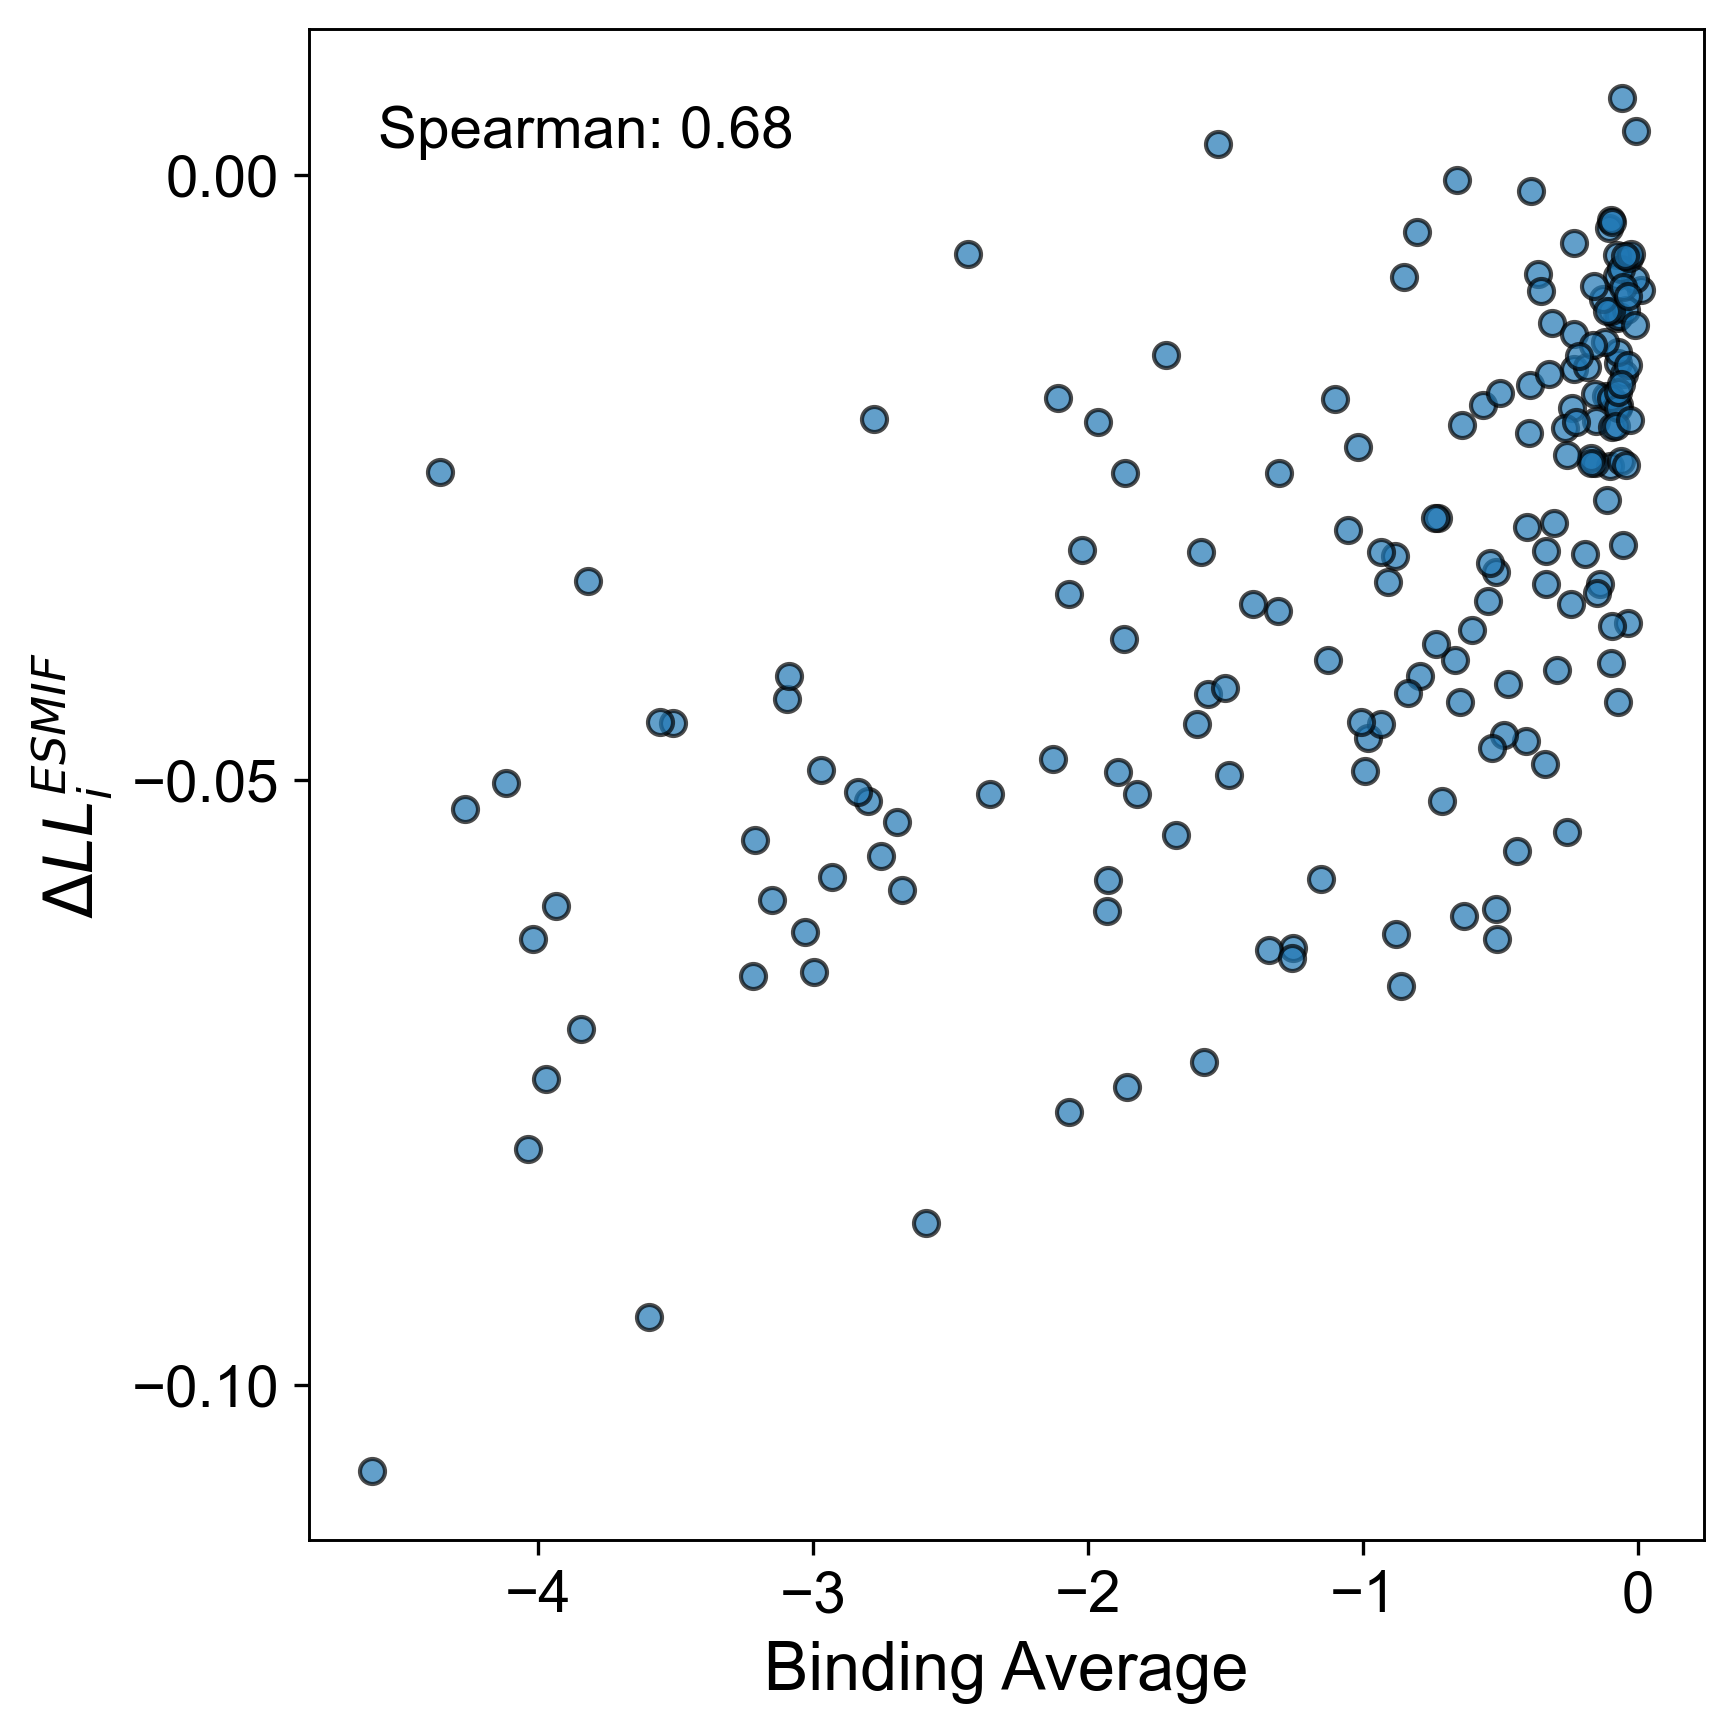

esmif_likelihood vs bind_avg
  Spearman: 0.679
  R² score: -0.739


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.metrics import r2_score
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Nature-style formatting
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.markersize": 6,
    "lines.linewidth": 2,
    "figure.dpi": 300
})

# --- Group and average numeric columns by site ---
df_bloom_avg = df_bloom.groupby('site_SARS2').agg(
    lambda x: x.mean() if np.issubdtype(x.dtype, np.number) else x.iloc[0]
).reset_index()

# --- Define metrics and likelihoods to compare ---
metrics = ['expr_avg', 'bind_avg']
likelihoods = ['likelihood', 'esmif_likelihood']
likelihood_labels = {
    'likelihood': r'$\Delta LL_i^{\mathrm{RBM}}$',
    'esmif_likelihood': r'$\Delta LL_i^{ESMIF}$',
}
metric_labels = {
    'expr_avg': 'Expression Average',
    'bind_avg': 'Binding Average'
}

# --- Loop through each pair and generate a plot ---
for metric in metrics:
    for likelihood in likelihoods:
        x = df_bloom_avg[metric]
        y = df_bloom_avg[likelihood]

        # Compute Spearman correlation and R²
        spearman_corr, _ = stats.spearmanr(x, y)
        r2 = r2_score(x, y)

        # Create figure
        fig, ax = plt.subplots(figsize=(6, 6))

        # Scatter plot
        ax.scatter(x, y, color='#1f77b4', alpha=0.7, edgecolor='black')

        # Labels
        ax.set_xlabel(metric_labels[metric])
        ax.set_ylabel(likelihood_labels[likelihood])

        # Annotation with Spearman correlation
        textstr = f"Spearman: {spearman_corr:.2f}"
        ax.text(
            0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top'
        )

        # Style
        ax.grid(False)
        ax.tick_params(labelsize=14)

        # Y-axis formatting
        if likelihood == 'esmif_likelihood':
            ax.yaxis.set_major_locator(MultipleLocator(0.05))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        # Black spines
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.7)

        # Save figure
        fname = f'figures/scatter_{likelihood}_{metric}.pdf'
        plt.tight_layout()
        plt.show()

        # Print stats
        print(f"{likelihood} vs {metric}")
        print(f"  Spearman: {spearman_corr:.3f}")
        print(f"  R² score: {r2:.3f}")
